<a href="https://colab.research.google.com/github/aarishaarif/Unsupervised-ml/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [ ]:
data = pd.read_csv('/content/Wine dataset.csv')
data.head()

,class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [ ]:
data.shape

(178, 14)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   class                         178 non-null    int64  
 1   Alcohol                       178 non-null    float64
 2   Malic acid                    178 non-null    float64
 3   Ash                           178 non-null    float64
 4   Alcalinity of ash             178 non-null    float64
 5   Magnesium                     178 non-null    int64  
 6   Total phenols                 178 non-null    float64
 7   Flavanoids                    178 non-null    float64
 8   Nonflavanoid phenols          178 non-null    float64
 9   Proanthocyanins               178 non-null    float64
 10  Color intensity               178 non-null    float64
 11  Hue                           178 non-null    float64
 12  OD280/OD315 of diluted wines  178 non-null    float64
 13  Proli

In [ ]:
data.describe()

,class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [ ]:
data.isnull().sum()

,0
class,0
Alcohol,0
Malic acid,0
Ash,0
Alcalinity of ash,0
Magnesium,0
Total phenols,0
Flavanoids,0
Nonflavanoid phenols,0
Proanthocyanins,0


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data['class'].value_counts()

,count
class,
2,71
1,59
3,48


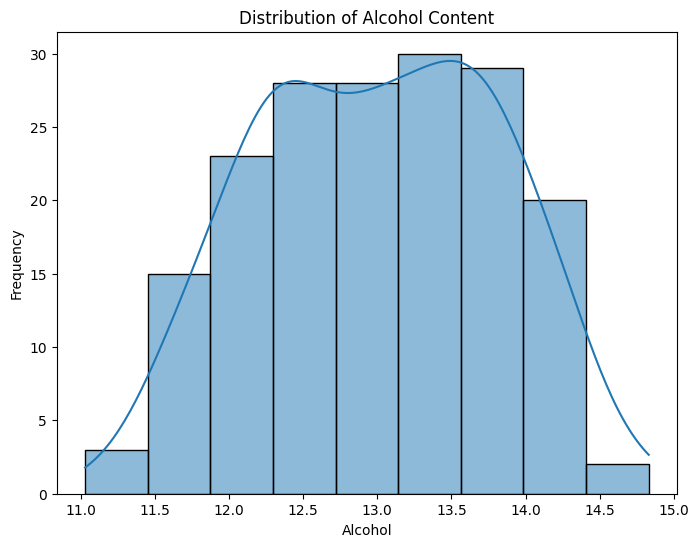

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(data['Alcohol'], kde=True)
plt.title('Distribution of Alcohol Content')
plt.xlabel('Alcohol')
plt.ylabel('Frequency')
plt.show()

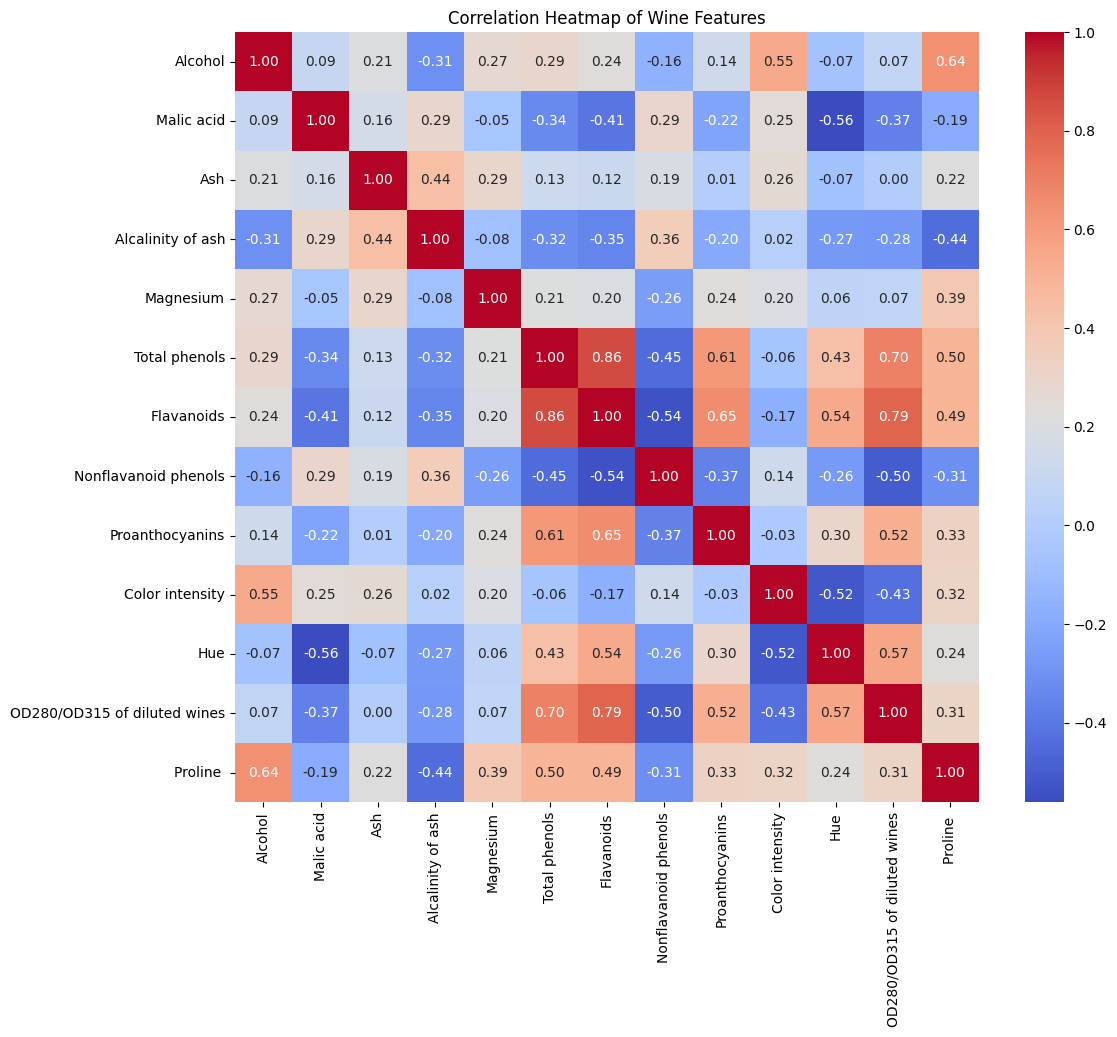

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(data.drop('class', axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Wine Features')
plt.show()

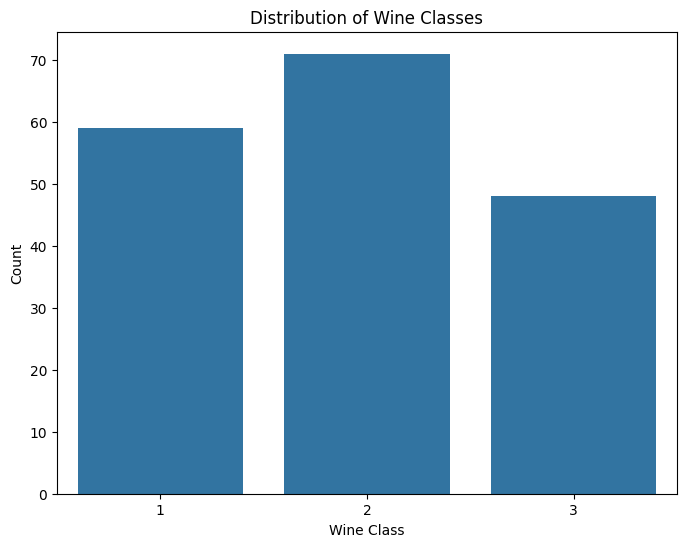

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='class', data=data)
plt.title('Distribution of Wine Classes')
plt.xlabel('Wine Class')
plt.ylabel('Count')
plt.show()

In [ ]:
data = data.drop('class', axis=1)
data.head()

,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


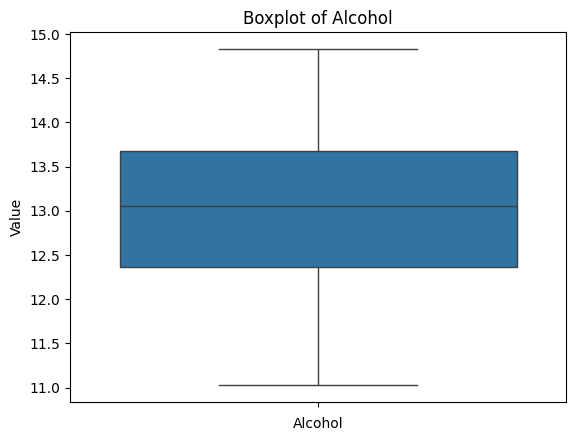

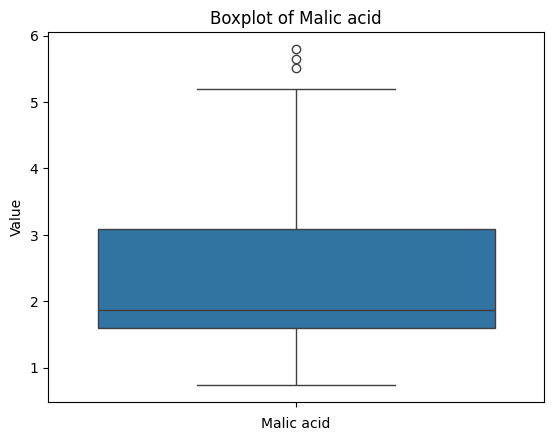

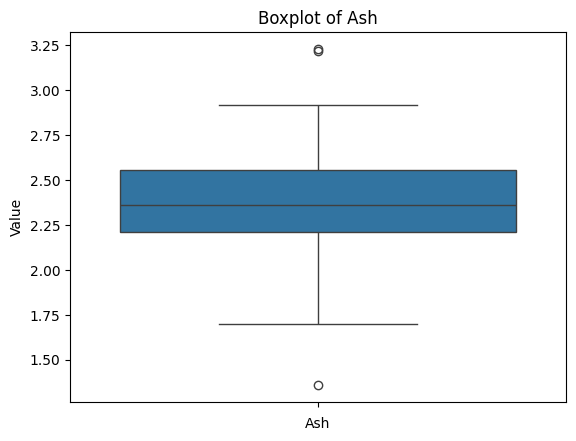

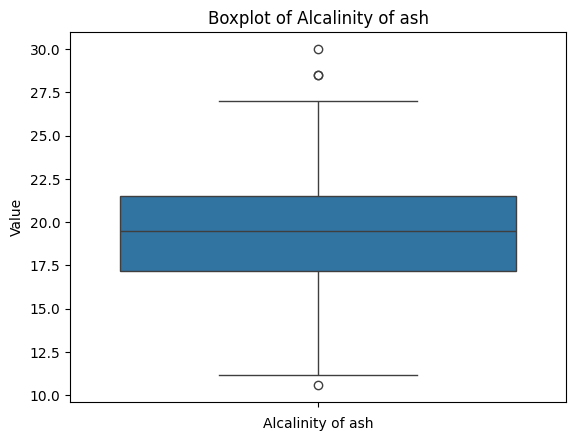

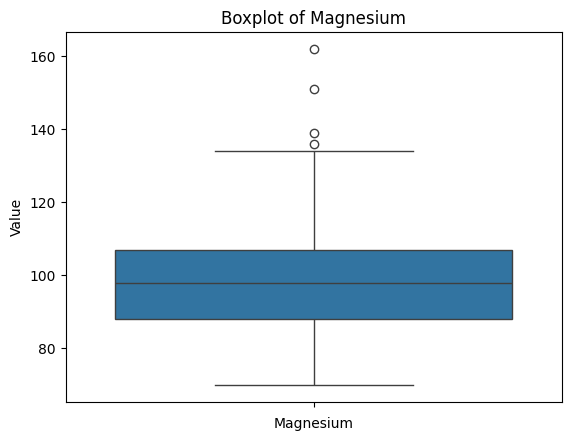

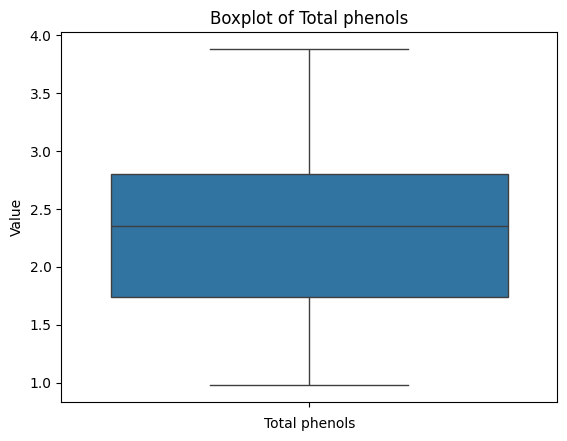

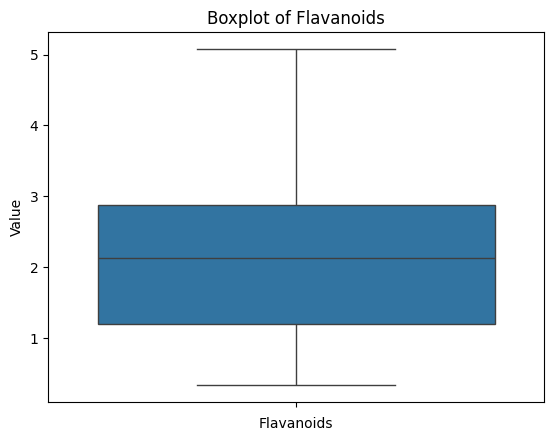

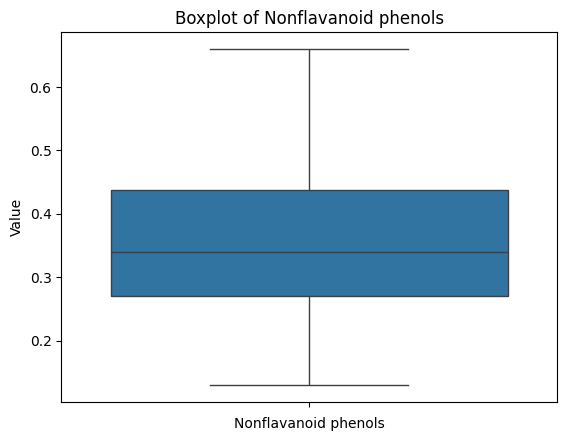

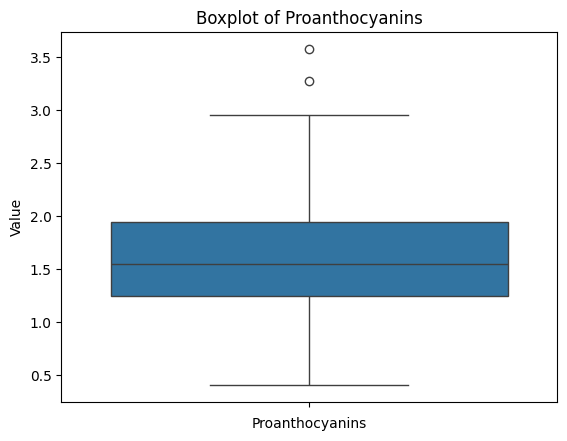

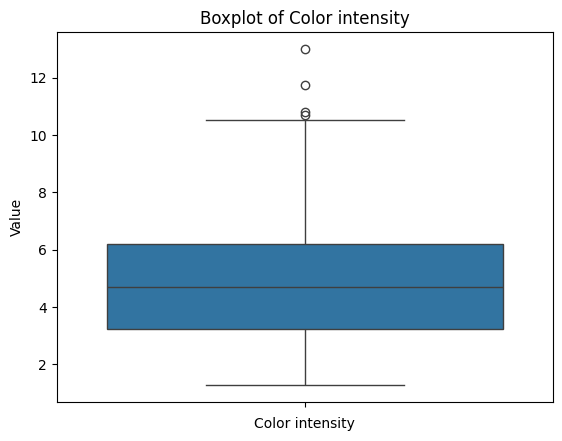

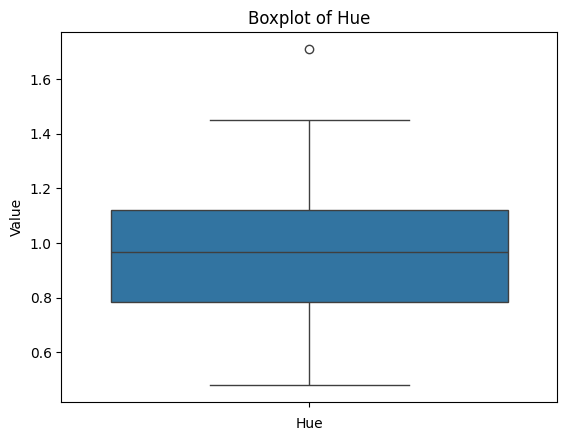

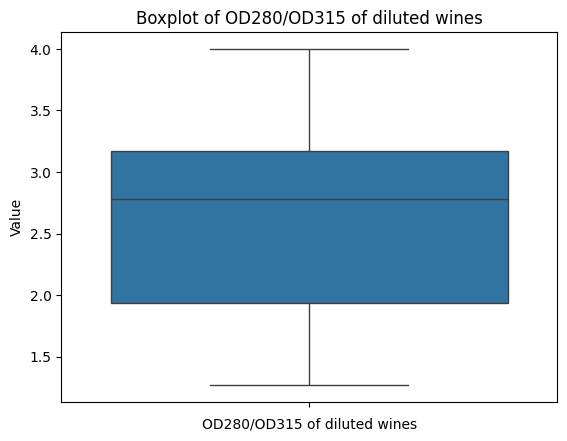

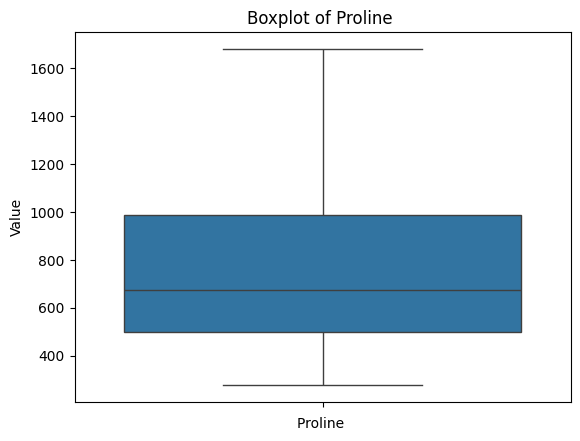

In [ ]:
num_cols = data.select_dtypes(include=np.number).columns
for col in num_cols:
  plt.figure()
  sns.boxplot(data[col])
  plt.title(f'Boxplot of {col}')
  plt.xlabel(col)
  plt.ylabel('Value')
  plt.show()

In [ ]:
cols_to_cap =['Hue','Color intensity','Proanthocyanins','Magnesium','Alcalinity of ash','Ash','Malic acid']
for col in cols_to_cap:
  Q1 = data[col].quantile(0.25)
  Q3 = data[col].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  data[col] = data[col].clip(lower_bound, upper_bound)

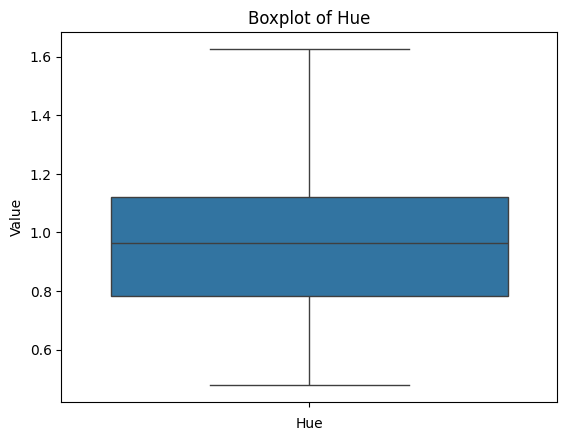

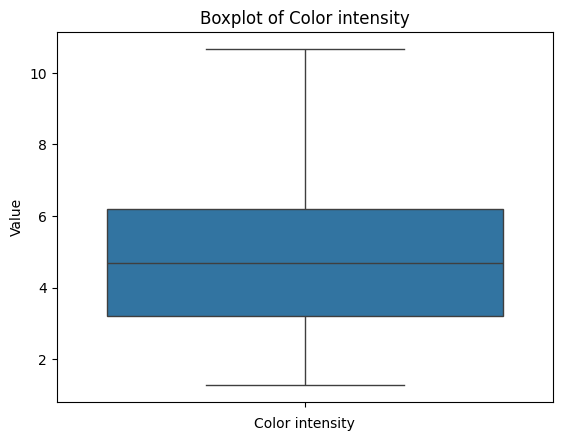

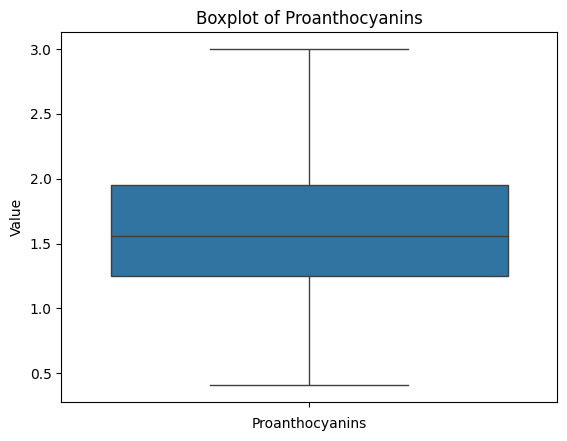

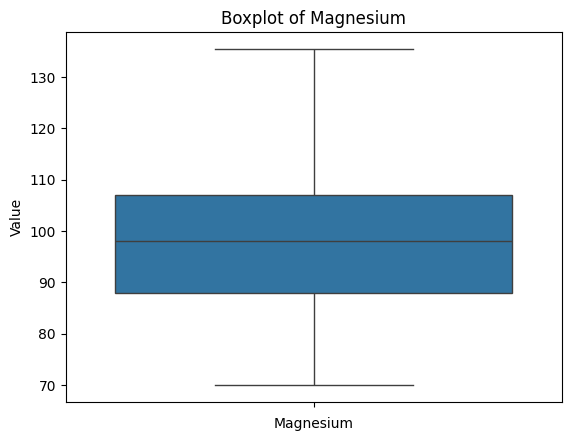

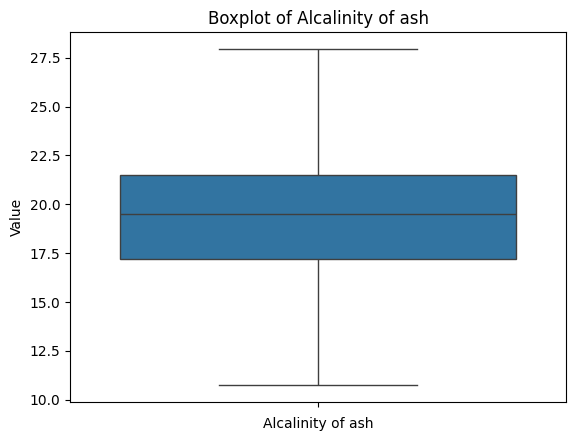

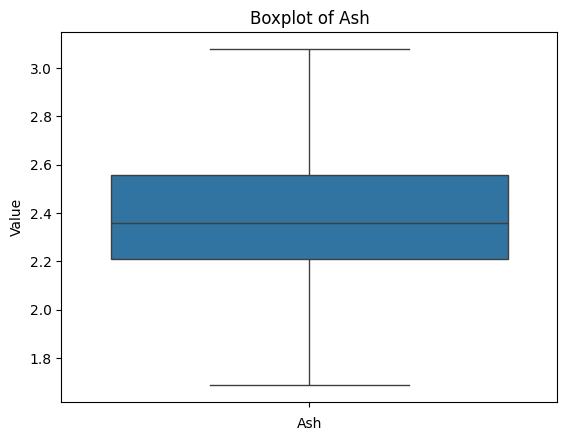

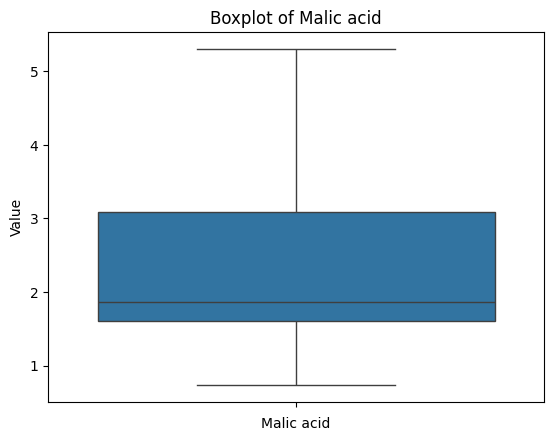

In [ ]:
for col in cols_to_cap:
  plt.figure()
  sns.boxplot(data[col])
  plt.title(f'Boxplot of {col}')
  plt.xlabel(col)
  plt.ylabel('Value')
  plt.show()

In [ ]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

In [ ]:
pca = PCA()
data_pca = pca.fit_transform(data_scaled)

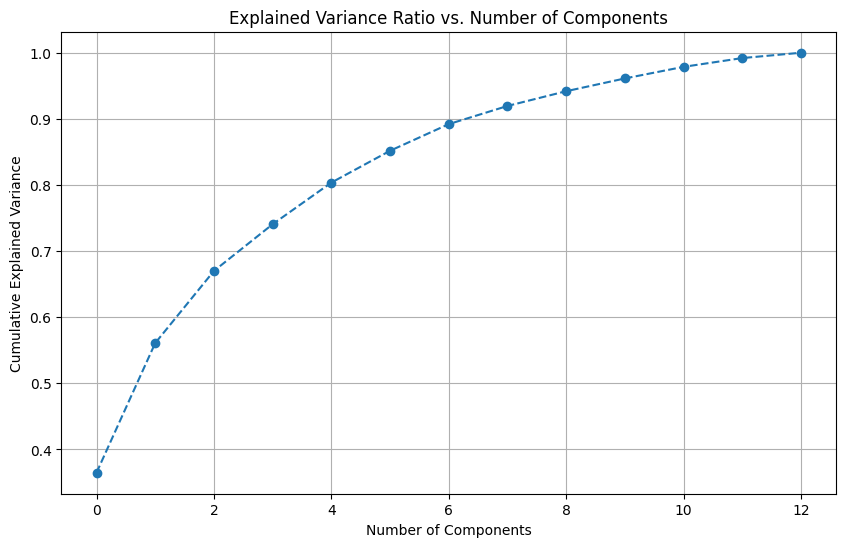

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance Ratio vs. Number of Components')
plt.grid(True)
plt.show()

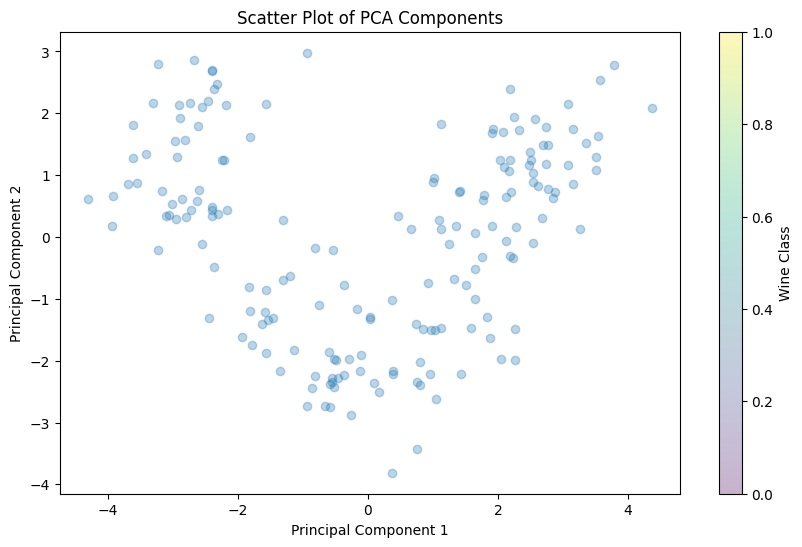

In [ ]:
pca_2 = PCA(n_components=2)
data_pca_2 = pca_2.fit_transform(data_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(data_pca_2[:, 0], data_pca_2[:, 1], alpha = 0.3)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Scatter Plot of PCA Components')
plt.colorbar(label='Wine Class')
plt.show()


In [ ]:
wcss = []
for i in range(1,11):
  km = KMeans(n_clusters=i,random_state=42)
  km.fit(data_scaled)
  wcss.append(km.inertia_)

<function matplotlib.pyplot.show(close=None, block=None)>

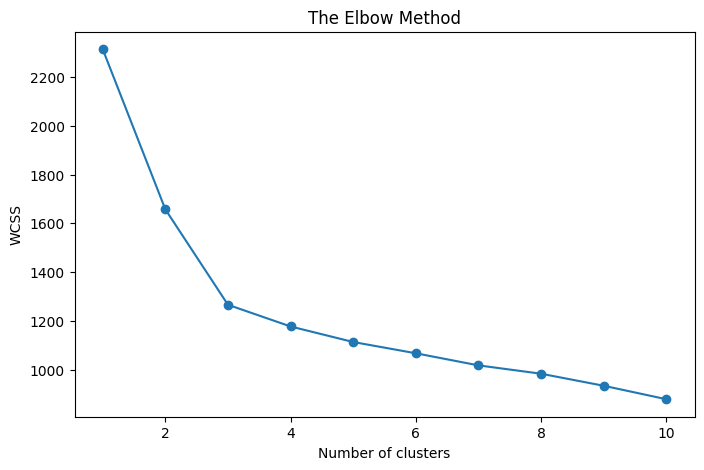

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker ='o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show

In [ ]:
km = KMeans(
    n_clusters=3,
    random_state=42)

In [ ]:
y_means = km.fit_predict(data_scaled)

In [ ]:
data['cluster']=y_means

In [ ]:
data.head()

,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline,cluster
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,2
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,2
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,2
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,2
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,2


In [ ]:
cluster_profile = data.groupby('cluster').mean()
cluster_profile

,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
cluster,,,,,,,,,,,,,
0,12.250923,1.889731,2.236288,20.056923,92.492308,2.247692,2.050000,0.357692,1.615231,2.973077,1.061419,2.803385,510.169231
1,13.134118,3.296373,2.417647,21.241176,98.666667,1.683922,0.818824,0.451961,1.145882,7.165098,0.691961,1.696667,619.058824
2,13.676774,1.997903,2.461573,17.420968,107.483871,2.847581,3.003226,0.292097,1.917581,5.453548,1.065484,3.163387,1100.225806


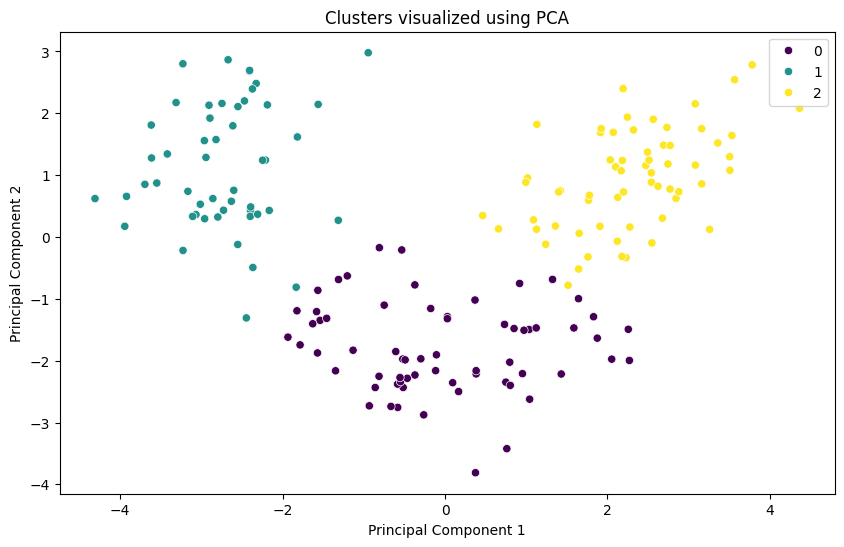

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=data_pca_2[:, 0], y=data_pca_2[:, 1], hue=y_means, palette='viridis', legend='full')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Clusters visualized using PCA')
plt.show()

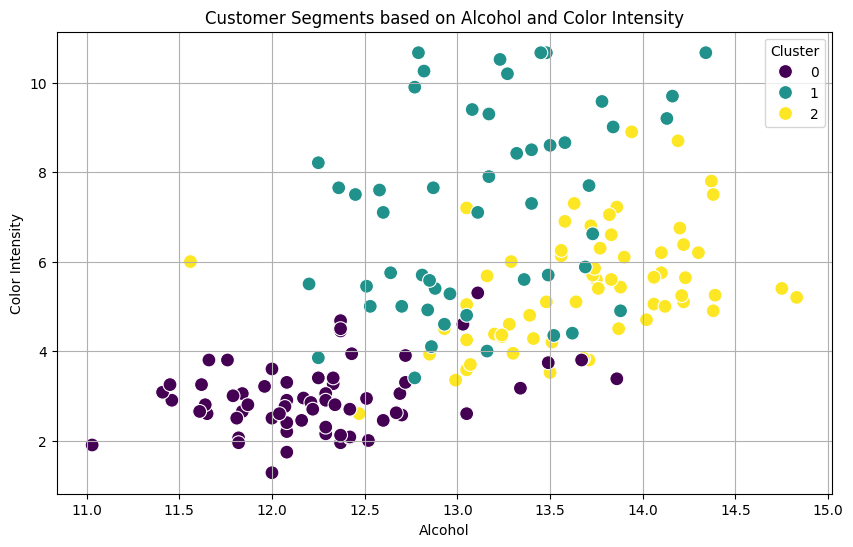

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=data['Alcohol'],
    y=data['Color intensity'],
    hue=data['cluster'],
    palette='viridis',
    s=100
)
plt.title('Customer Segments based on Alcohol and Color Intensity')
plt.xlabel('Alcohol')
plt.ylabel('Color Intensity')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

In [ ]:
score = silhouette_score(data_scaled, y_means)
print ('silhouette_score:' , score)

silhouette_score: 0.2854626783251893


In [ ]:
for k in range(2,11):

    km = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = km.fit_predict(data_scaled)

    score = silhouette_score(data_scaled, labels)

    print(f"K={k}, Score={score}")

K=2, Score=0.2646474940980715
K=3, Score=0.2854626783251893
K=4, Score=0.2267890649847744
K=5, Score=0.1788244676430536
K=6, Score=0.16387931887105264
K=7, Score=0.161107690991123
K=8, Score=0.16868333333102986
K=9, Score=0.1675013402477462
K=10, Score=0.13683521178782293


In [ ]:
score_pca = silhouette_score(data_pca_2, y_means)
print("Silhouette Score (PCA):", score_pca)

Silhouette Score (PCA): 0.5578427422387213
